In [46]:
import os
import torch
import numpy as np
import random

def seed_everything(seed):
    """
    Set random seed for reproducibility
    """
    # 1. Python & Numpy
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # 2. PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"🔒 Locked Random Seed: {seed}")


In [47]:



def seed_everything_random():
    """
    Tạo random seed, set seed đó, và return seed để bạn biết
    """
    # Tạo random seed
    random_seed = random.randint(0, 999999)
    
    # Set seed
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)
    
    # Để reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    return random_seed


In [48]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [49]:
#load data
df_men =pd.read_csv(r"/home/ducm/RERUM/dataset/Hillstrom-Men.csv")
df_men = df_men.drop(columns="Unnamed: 0")
print ("---------------------------")
print ("null count:")
print (df_men.isnull().sum())
print ("---------------------------")
print(df_men.dtypes)
print ("---------------------------")
print ("labels:")
print(df_men.columns.tolist())
print ("---------------------------")
print("data shape:")
print(df_men.shape)
print("spend")

---------------------------
null count:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
visit              0
conversion         0
spend              0
treatment          0
dtype: int64
---------------------------
recency              int64
history_segment      int64
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
visit                int64
conversion           int64
spend              float64
treatment            int64
dtype: object
---------------------------
labels:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'visit', 'conversion', 'spend', 'treatment']
---------------------------
data shape:
(42613, 12)
spend


In [50]:
#Hillstrom-men
#split num and cate
cate_cols = ['zip_code', 'channel', 'mens', "womens"]
num_cols = ['recency', 'history_segment', 'history']
#split x y t
y_men = df_men["spend"]
t_men = df_men["treatment"]
x_men = df_men.drop(columns=["spend", "treatment", "visit", "conversion"])

#train test split - stratify CHỈ bằng treatment
x_men_train, x_men_test, t_men_train, t_men_test, y_men_train, y_men_test = train_test_split(
    x_men, t_men.values, y_men.values,
    test_size=0.3, random_state=42, stratify= t_men
)

# Tạo stratify cho val split - chỉ dùng treatment
stratify_var_train = pd.Series(t_men_train)

x_men_train, x_men_val, t_men_train, t_men_val, y_men_train, y_men_val = train_test_split(
    x_men_train, t_men_train, y_men_train,
    test_size=(1/7), random_state=42, stratify= t_men_train
)

# Fit get_dummies trên train, sau đó align với val/test
x_men_train_encode = pd.get_dummies(x_men_train, columns=cate_cols, drop_first=True)
x_men_val_encode = pd.get_dummies(x_men_val, columns=cate_cols, drop_first=True)
x_men_test_encode = pd.get_dummies(x_men_test, columns=cate_cols, drop_first=True)

# Align columns
x_men_val_encode = x_men_val_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)
x_men_test_encode = x_men_test_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)

scaler = StandardScaler()
x_men_train= scaler.fit_transform(x_men_train_encode)
x_men_val = scaler.transform(x_men_val_encode)
x_men_test = scaler.transform(x_men_test_encode)

print ("✅ Train/Val/Test split with stratification ONLY by treatment (NO DATA LEAKAGE)")
print (f"Train: {x_men_train.shape}, Val: {x_men_val.shape}, Test: {x_men_test.shape}")
print (f"Treatment distribution - Train: {np.mean(t_men_train):.2%}, Val: {np.mean(t_men_val):.2%}, Test: {np.mean(t_men_test):.2%}")
print (f"Spend mean - Train: {np.mean(y_men_train):.2f}, Val: {np.mean(y_men_val):.2f}, Test: {np.mean(y_men_test):.2f}")

✅ Train/Val/Test split with stratification ONLY by treatment (NO DATA LEAKAGE)
Train: (25567, 10), Val: (4262, 10), Test: (12784, 10)
Treatment distribution - Train: 50.00%, Val: 50.00%, Test: 50.00%
Spend mean - Train: 1.00, Val: 0.95, Test: 1.14


In [51]:
#Transform to tensor
def to_tensor(df):
    return torch.tensor(df, dtype=torch.float32)

x_men_train_t = to_tensor(x_men_train)
x_men_val_t = to_tensor(x_men_val)
x_men_test_t = to_tensor(x_men_test)

y_men_train_t = to_tensor(y_men_train).unsqueeze(1)
y_men_val_t = to_tensor(y_men_val).unsqueeze(1)
y_men_test_t = to_tensor(y_men_test).unsqueeze(1)

t_men_train_t = to_tensor(t_men_train.astype(float)).unsqueeze(1)
t_men_val_t = to_tensor(t_men_val.astype(float)).unsqueeze(1)
t_men_test_t = to_tensor(t_men_test.astype(float)).unsqueeze(1)

# sampler = get_sampler(y_men_train_t, target_positive_ratio=0.2)

#Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

batch_size = 800
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

print ("-------------------------------------------------------------")
print ("✅Completed tranform to tensor✅")
print (f"Shape of train: x={x_men_train_t.shape}; y ={y_men_train_t.shape}; t={t_men_train_t.shape}")
print (f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print (f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅Completed tranform to tensor✅
Shape of train: x=torch.Size([25567, 10]); y =torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 10]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 10]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


Evaluation metrics

In [52]:
from metrics import auuc, auqc, lift, krcc

Build Model

In [53]:
from dragonnet import Dragonnet

In [54]:
print("📊 Data Distribution Check:")
print(f"Y train: mean={y_men_train.mean():.4f}, std={y_men_train.std():.4f}")
print(f"Y train zeros: {(y_men_train == 0).sum()} / {len(y_men_train)} ({(y_men_train == 0).sum()/len(y_men_train)*100:.1f}%)")
print(f"\nTreatment balance:")
print(f"  Train: {(t_men_train == 1).sum()} treated, {(t_men_train == 0).sum()} control")
print(f"  Test:  {(t_men_test == 1).sum()} treated, {(t_men_test == 0).sum()} control")

📊 Data Distribution Check:
Y train: mean=1.0015, std=14.5993
Y train zeros: 25338 / 25567 (99.1%)

Treatment balance:
  Train: 12784 treated, 12783 control
  Test:  6392 treated, 6392 control


In [55]:
epochs = 300
alpha = 1
beta = 0
lr = 5e-4
wd = 1e-4
early_stop_metric = "loss"
ema = True
ema_alpha = 0.15
patience = 30
shared_dropout = 0
outcome_droupout = 0 
shared_hidden = 200
outcome_hidden = 100
early_stop_start_epoch = 0
print (f" epochs = {epochs}")
print (f" alpha = {alpha}")
print (f" beta = {beta}")
print (f" learning rate = {lr}")
print (f" weight decay = {wd}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" share dropout = {shared_dropout}")
print (f" outcome dropout = {outcome_droupout}")
print (f" shared hidden = {shared_hidden}")
print (f" outcome hidden = {outcome_hidden}")

 epochs = 300
 alpha = 1
 beta = 0
 learning rate = 0.0005
 weight decay = 0.0001
 early stop = loss
 use ema = True
 ema alpha = 0.15
 patience = 30
 share dropout = 0
 outcome dropout = 0
 shared hidden = 200
 outcome hidden = 100


🔒 Locked Random Seed: 412312
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 30 epochs
Epoch 1/300 | Base Loss: 77.7411 | Tarreg Loss: 0.000000 | Total Loss: 77.7411 | Val Loss: 376.8766 | Val Qini: -0.4463 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 156.5444 | Tarreg Loss: 0.000000 | Total Loss: 156.5444 | Val Loss: 376.8437 | Val Qini: -0.3516 ⭐ NEW BEST (lowest loss)
Epoch 3/300 | Base Loss: 46.8870 | Tarreg Loss: 0.000000 | Total Loss: 46.8870 | Val Loss: 376.9010 | Val Qini: -0.6336 (patience: 1/30)
Epoch 4/300 | Base Loss: 137.0524 | Tarreg Loss: 0.000000 | Total Loss: 137.0524 | Val Loss: 376.6562 | Val Qini: -0.6077 ⭐ NEW BEST (lowest loss)
Epoch 5/300 | Base Loss: 553.1196 | Tarreg Loss: 0.000000 | Total Loss: 553.1196 | Val Loss: 376.6848 | Val Qini: -0.6538 (patience: 1/30)
Epoch 6/300 | Base Loss: 103.2327 | Tarreg Loss: 0.000000 | Total Loss: 1

/home/ducm/RERUM/dragonnet/dragonnet.py:319: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


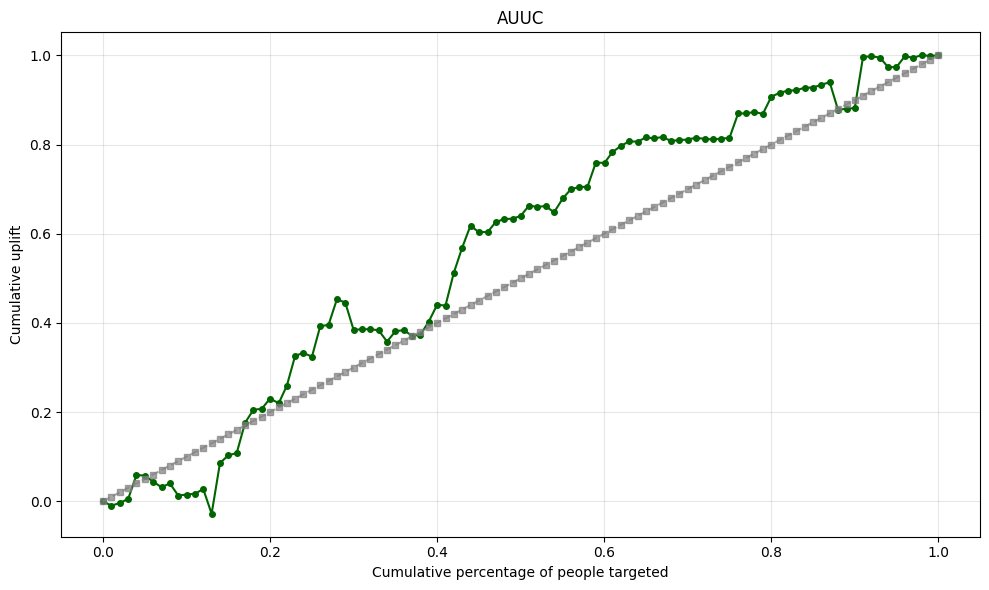

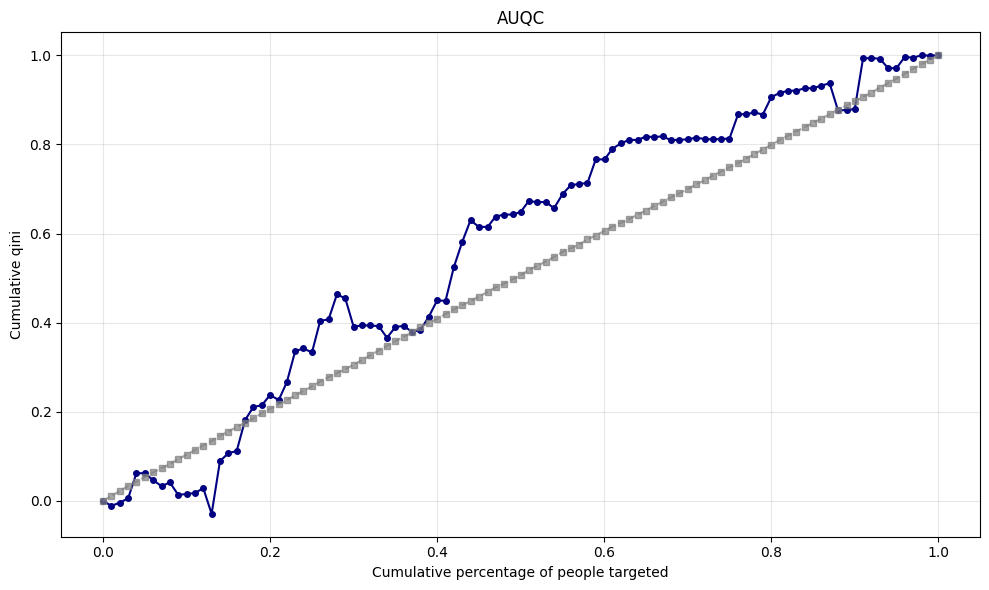

----------------------------------------
AUUC: 0.567
AUQC: 0.571
Lift: 1.314
KRCC: 0.068
seed: 412312


In [56]:
seed = 412312
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start_epoch)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")

🔒 Locked Random Seed: 42
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 30 epochs
Epoch 1/300 | Base Loss: 725.2994 | Tarreg Loss: 0.000000 | Total Loss: 725.2994 | Val Loss: 377.4109 | Val Qini: -0.7226 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 249.4214 | Tarreg Loss: 0.000000 | Total Loss: 249.4214 | Val Loss: 376.5857 | Val Qini: -0.5181 ⭐ NEW BEST (lowest loss)
Epoch 3/300 | Base Loss: 90.9852 | Tarreg Loss: 0.000000 | Total Loss: 90.9852 | Val Loss: 376.8092 | Val Qini: -0.4904 (patience: 1/30)
Epoch 4/300 | Base Loss: 49.7265 | Tarreg Loss: 0.000000 | Total Loss: 49.7265 | Val Loss: 376.8055 | Val Qini: -0.3907 (patience: 2/30)
Epoch 5/300 | Base Loss: 165.1379 | Tarreg Loss: 0.000000 | Total Loss: 165.1379 | Val Loss: 376.8513 | Val Qini: -0.4563 (patience: 3/30)
Epoch 6/300 | Base Loss: 696.4307 | Tarreg Loss: 0.000000 | Total Loss: 696.4307 | Va

/home/ducm/RERUM/dragonnet/dragonnet.py:319: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


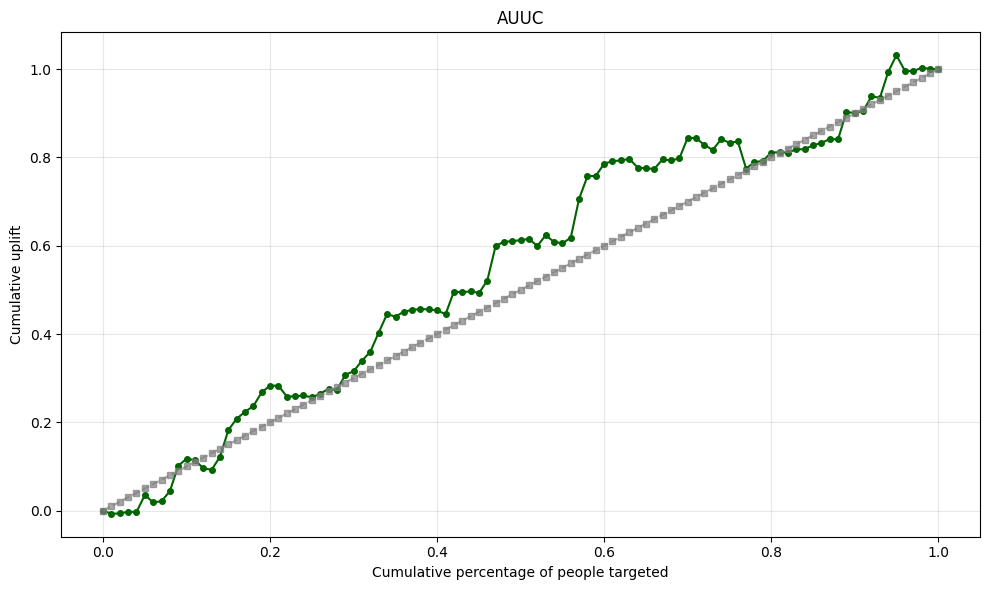

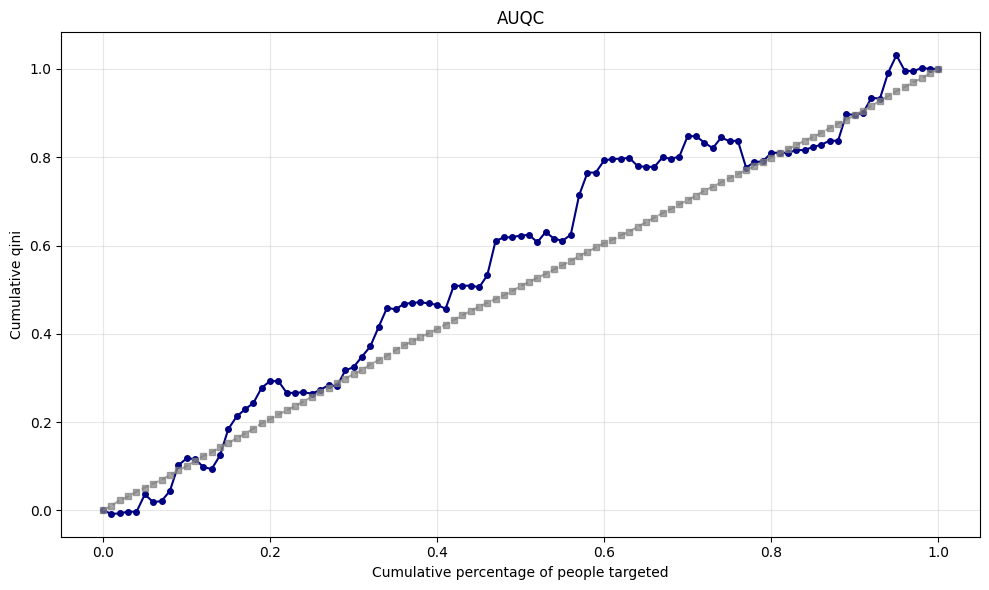

----------------------------------------
AUUC: 0.550
AUQC: 0.555
Lift: 1.080
KRCC: 0.043
seed: 42


In [57]:
seed = 42
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start_epoch)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")

🔒 Locked Random Seed: 1874
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 30 epochs
Epoch 1/300 | Base Loss: 1461.6626 | Tarreg Loss: 0.000000 | Total Loss: 1461.6626 | Val Loss: 376.9043 | Val Qini: -0.8388 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 446.0366 | Tarreg Loss: 0.000000 | Total Loss: 446.0366 | Val Loss: 376.9645 | Val Qini: -0.3243 (patience: 1/30)
Epoch 3/300 | Base Loss: 693.2531 | Tarreg Loss: 0.000000 | Total Loss: 693.2531 | Val Loss: 376.8125 | Val Qini: -0.6131 ⭐ NEW BEST (lowest loss)
Epoch 4/300 | Base Loss: 95.9482 | Tarreg Loss: 0.000000 | Total Loss: 95.9482 | Val Loss: 376.7525 | Val Qini: -0.7999 ⭐ NEW BEST (lowest loss)
Epoch 5/300 | Base Loss: 173.8228 | Tarreg Loss: 0.000000 | Total Loss: 173.8228 | Val Loss: 376.6198 | Val Qini: -0.6910 ⭐ NEW BEST (lowest loss)
Epoch 6/300 | Base Loss: 583.9500 | Tarreg Loss: 0.000000 | Tot

/home/ducm/RERUM/dragonnet/dragonnet.py:319: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


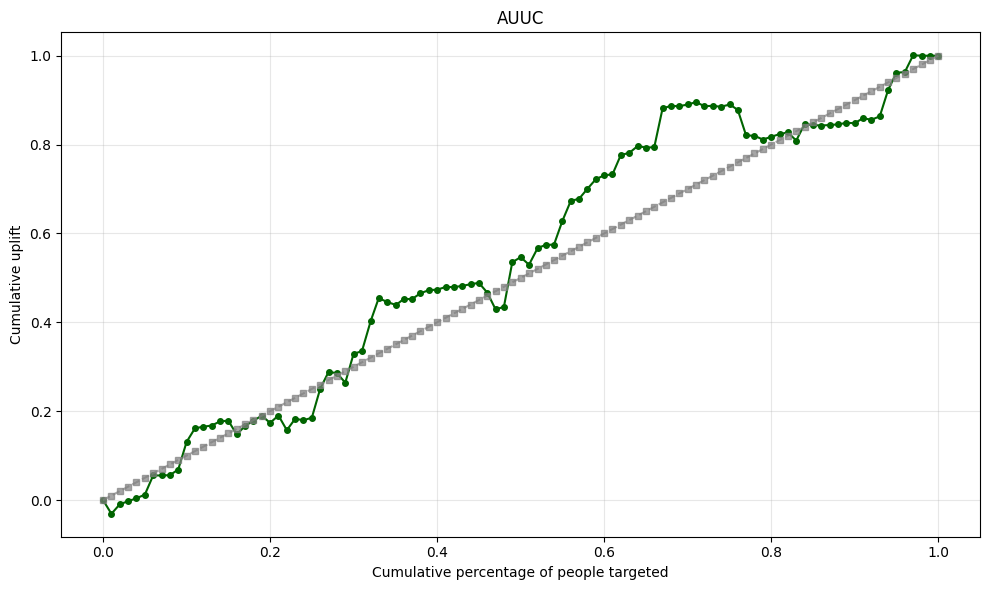

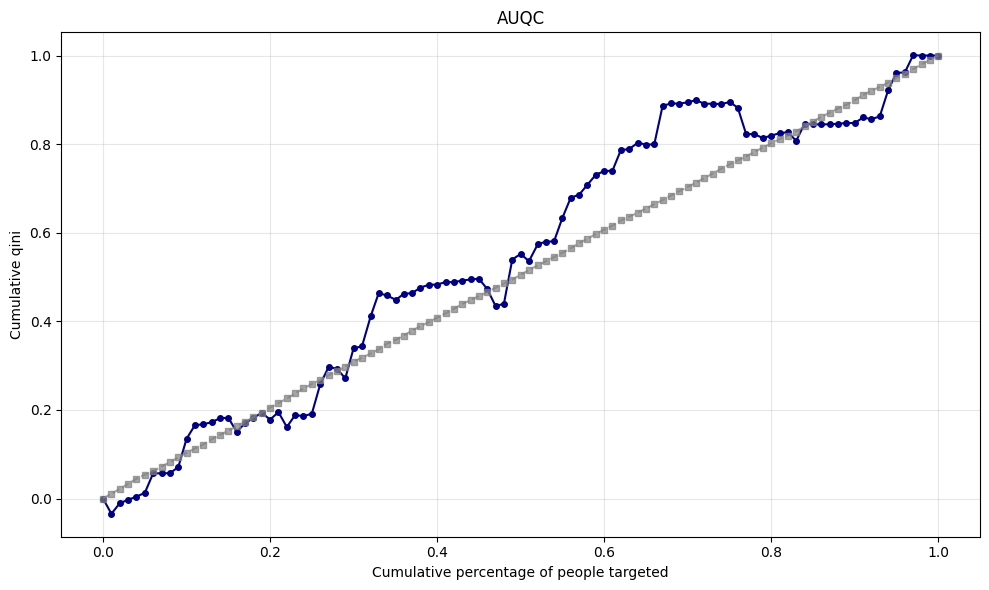

----------------------------------------
AUUC: 0.541
AUQC: 0.545
Lift: 1.127
KRCC: 0.119
seed: 1874


In [58]:
seed = 1874
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start_epoch)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")

In [59]:
seed = 902745
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start_epoch)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")     

🔒 Locked Random Seed: 902745
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 30 epochs
Epoch 1/300 | Base Loss: 698.0057 | Tarreg Loss: 0.000000 | Total Loss: 698.0057 | Val Loss: 377.1227 | Val Qini: -0.6769 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 679.6691 | Tarreg Loss: 0.000000 | Total Loss: 679.6691 | Val Loss: 377.0053 | Val Qini: -0.6901 ⭐ NEW BEST (lowest loss)
Epoch 3/300 | Base Loss: 361.4486 | Tarreg Loss: 0.000000 | Total Loss: 361.4486 | Val Loss: 377.1927 | Val Qini: -0.8280 (patience: 1/30)
Epoch 4/300 | Base Loss: 1251.4377 | Tarreg Loss: 0.000000 | Total Loss: 1251.4377 | Val Loss: 377.0854 | Val Qini: -0.4552 (patience: 2/30)
Epoch 5/300 | Base Loss: 531.4337 | Tarreg Loss: 0.000000 | Total Loss: 531.4337 | Val Loss: 377.2559 | Val Qini: -0.5212 (patience: 3/30)
Epoch 6/300 | Base Loss: 149.5274 | Tarreg Loss: 0.000000 | Total Loss: 149

Exception ignored in: <function _releaseLock at 0x729d1c3b1870>
Traceback (most recent call last):
  File "/home/ducm/miniconda3/envs/dl/lib/python3.10/logging/__init__.py", line 228, in _releaseLock
    def _releaseLock():
KeyboardInterrupt: 


RuntimeError: DataLoader worker (pid(s) 1412408) exited unexpectedly

🔒 Locked Random Seed: 1
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 300 epochs, select model with lowest validation loss
   Patience: 30 epochs
Epoch 1/300 | Base Loss: 1020.7480 | Tarreg Loss: 519.552124 | Total Loss: 1540.3002 | Val Loss: 378.3555 | Val Qini: -0.3237 ⭐ NEW BEST (lowest loss)
Epoch 2/300 | Base Loss: 427.6333 | Tarreg Loss: 215.624588 | Total Loss: 643.2579 | Val Loss: 377.5679 | Val Qini: -0.2468 ⭐ NEW BEST (lowest loss)
Epoch 3/300 | Base Loss: 532.7366 | Tarreg Loss: 264.758148 | Total Loss: 797.4948 | Val Loss: 377.2888 | Val Qini: -0.5455 ⭐ NEW BEST (lowest loss)
Epoch 4/300 | Base Loss: 1190.4993 | Tarreg Loss: 573.702820 | Total Loss: 1764.2021 | Val Loss: 377.1422 | Val Qini: -0.3790 ⭐ NEW BEST (lowest loss)
Epoch 5/300 | Base Loss: 861.5945 | Tarreg Loss: 426.175873 | Total Loss: 1287.7704 | Val Loss: 376.9459 | Val Qini: -0.5573 ⭐ NEW BEST (lowest loss)
Epoch 6/300 | Base Loss: 260.8109 | Tarreg 

/home/ducm/RERUM/dragonnet/dragonnet.py:319: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


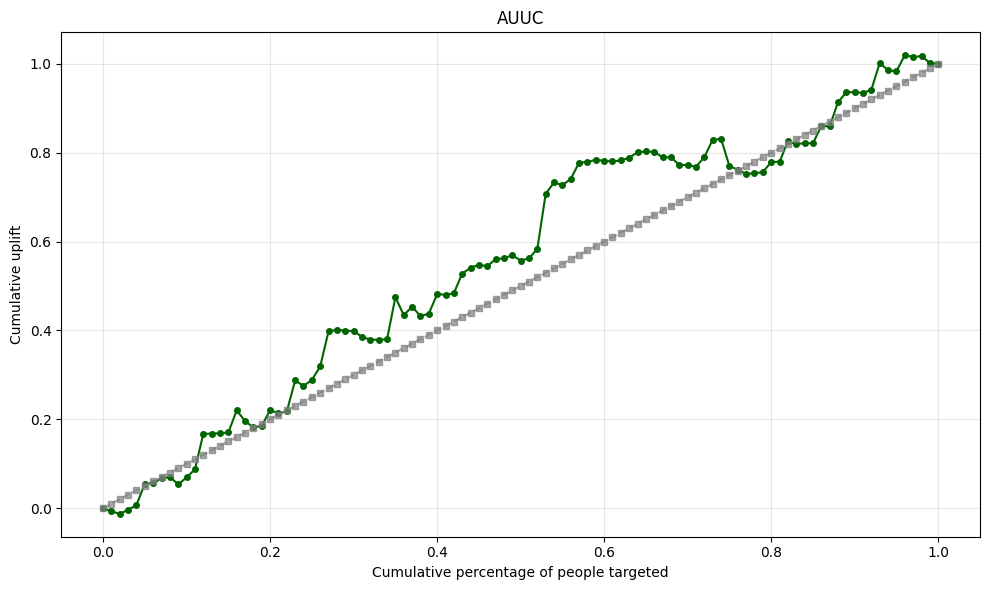

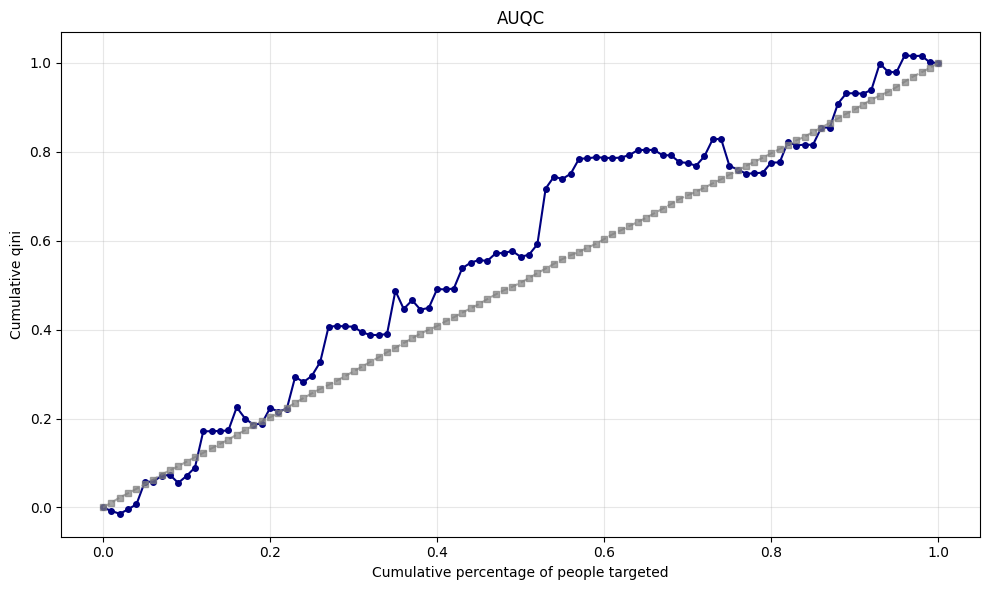

----------------------------------------
AUUC: 0.558
AUQC: 0.561
Lift: 1.362
KRCC: 0.050
seed: 1


In [ ]:
seed = 1
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start_epoch)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")

print ("Evaluating baseline🔃🔃🔃")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_men_test_t_on_device = x_men_test_t.to(device)

y0_pred, y1_pred, _,_ = dragonnet.predict(x_men_test_t_on_device)

# Move predicted tensors back to CPU before converting to numpy arrays
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()

y_true = y_men_test_t.cpu().numpy().flatten() # Ensure true labels are also on CPU if they were ever moved
t_true = t_men_test_t.cpu().numpy().flatten() # Ensure true treatments are also on CPU if they were ever moved

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins= 100)

print ("-"*40)
print (f"AUUC: {auuc_score:.3f}")
print (f"AUQC: {auqc_score:.3f}")
print (f"Lift: {lift_score:.3f}")
print (f"KRCC: {krcc_score:.3f}")
print (f"seed: {seed}")